In [22]:
# 5.1 

clusters = ['Hyades',
            'Pleiades', 
            'Coma Star Cluester',
            'Omicron Velorum Cluster', 
            'Butterfly Cluster'
           ]

with open('galaxies.txt', 'w') as f:
    for item in clusters:
        f.write(f"{item}\n") # Doing this we write each item followed by a line jump.

with open('galaxies.txt', 'r') as f:
    for item, line in enumerate(f, start=1):
        print(f"Galaxy cluster {item} is {line.rstrip()}")
    
    

Galaxy cluster 1 is Hyades
Galaxy cluster 2 is Pleiades
Galaxy cluster 3 is Coma Star Cluester
Galaxy cluster 4 is Omicron Velorum Cluster
Galaxy cluster 5 is Butterfly Cluster


In [ ]:
# q 5.2

import numpy as np

data = [1,   11,
        2,   12,
        3,   13,
        4,   14,
        5,   15,
        6,   16,
        7,   17,
        8,   18,
        9,   19,
        10,   20]

with open ('random_ascii.txt', 'w') as f:
   for i in range(0, len(data), 2):
       col1 = data[i]
       col2 = data[i+1]
       f.write(f"{col1}, {col2}\n")

       
# Cuando utilizas np.loadtxt(), NO necesitas usar with open(...) as f: !!!

file_name = input("Enter name of file: ")
    
x, y = np.loadtxt(file_name, delimiter=',', usecols=(0,1), unpack=True) # unpack allows for unpacking data into separate arrays.
   
print(f"Array x: {x}")
print(f"Array y: {y}")

print(f"The minimum and maximum values in array x are, respectively: {x.min()}, {x.max()}")
print(f"The mean of x is: {x.mean()}")

print()

print(f"The minimum and maximum values in array y are, respectively: {y.min()}, {y.max()}")
print(f"The mean of y is: {y.mean()}")

print()

# New array
y_med = np.median(y)
y2 = (y - y_med)**2

new_array = np.array(y2)

print("y2 = ", new_array)

In [ ]:
# 5.4 
A = numpy.zeros((5,4))
B = numpy.arange(6).reshape(3,2)+10

In [24]:
# q 5.6

import numpy as np

# Question 1

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate((a, b)))

print ()

# Question 2

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print(np.concatenate((a, b)))
print()
print(np.concatenate((a, b), axis=0))  # By default axis is set to 0
print()
print(np.concatenate((a, b), axis=None))

[1 2 3 4 5 6]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[1 2 3 4 5 6 7 8]


In [ ]:
# 5.7
# What’s the memory usage (i.e. number of bytes in memory) of array:

a = numpy.arange(60, dtype=np.complex)

a = numpy.arange(60, dtype=np.int8)

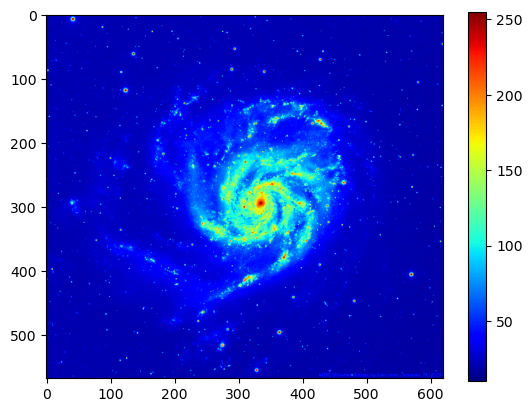

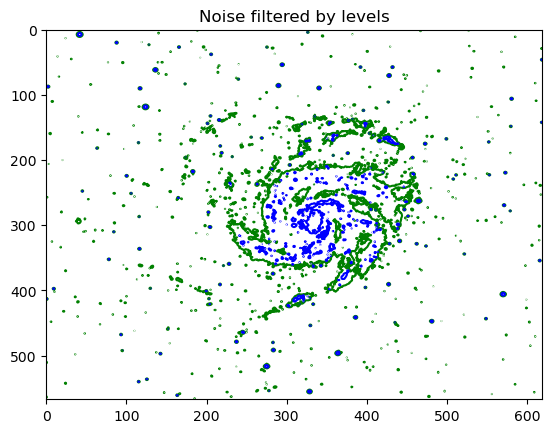

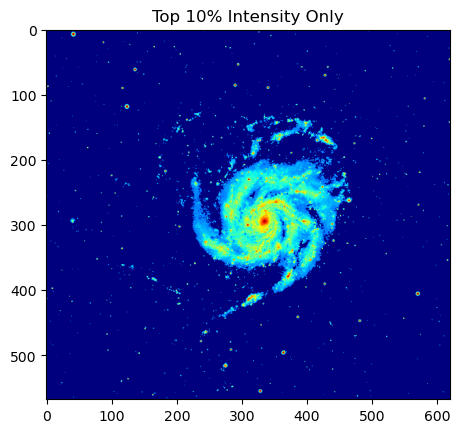

In [31]:
# q 5.9


import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

data = iio.imread('m101BW.jpg')

plt.figure()
plt.imshow(data, cmap='jet')
plt.colorbar()
plt.show()

# Countour plot 
levels = np.linspace(70, 250, 10) # 10 contour levels from intensity 50 to 250.

plt.figure()
#plt.contour(data , levels=levels)
plt.contour(data, levels=[70,150], colors=['g', 'b'])
plt.title('Noise filtered by levels')
plt.gca().invert_yaxis()
plt.show()


# Filtering image
threshold = np.percentile(data, 90)
high_intensity_data = np.where(data >= threshold, data, 0) # (condition, keep hight intensity data, the rest goes to zero)

plt.figure()
plt.imshow(high_intensity_data, cmap='jet')
plt.title("Top 10% Intensity Only")
plt.show()

Z-profile statistics at (x_mid, y_mid):
Max: 0.0606
Min: 0.00482
Sum: 0.89154
Mean: 0.0222885
Std Dev: 0.012699434544498428


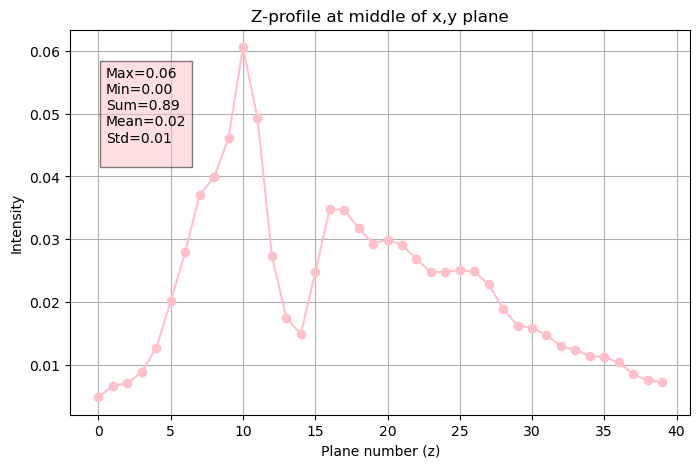

In [9]:
# q 5.10

import numpy as np
import matplotlib.pyplot as plt

# Read ASCII data
data = np.loadtxt('ngc6946.txt')

# Original file is flat so we have to reshape it to (z, y, x)
data_cube = data.reshape((40, 50, 70)) # (40 planes, 50 rows, 70 columns)

# Select point near the middle of x and y
x_mid = 70 // 2 # middle cloumn
y_mid = 50 // 2 # middle row

# Extract z-profile at this point
z_profile = data_cube[:, y_mid, x_mid] # all z planes at (x_mid, y_mid)

# Elemetary statistics for the extracted profile
print("Z-profile statistics at (x_mid, y_mid):")
print("Max:", z_profile.max())
print("Min:", z_profile.min())
print("Sum:", z_profile.sum())
print("Mean:", z_profile.mean())
print("Std Dev:", z_profile.std())

plt.figure(figsize=(8,5))
plt.plot(z_profile, marker='o', color='pink', linestyle='-')
plt.xlabel("Plane number (z)")
plt.ylabel("Intensity")
plt.title("Z-profile at middle of x,y plane")

stats_text = (f"Max={z_profile.max():.2f}\n"
              f"Min={z_profile.min():.2f}\n"
              f"Sum={z_profile.sum():.2f}\n"
              f"Mean={z_profile.mean():.2f}\n"
              f"Std={z_profile.std():.2f}\n")

plt.text(0.5, z_profile.max() * 0.95, stats_text, 
         fontsize=10, 
         bbox=dict(facecolor='pink', alpha=0.5), # Adds a background box
         verticalalignment='top')

plt.grid()
plt.show()


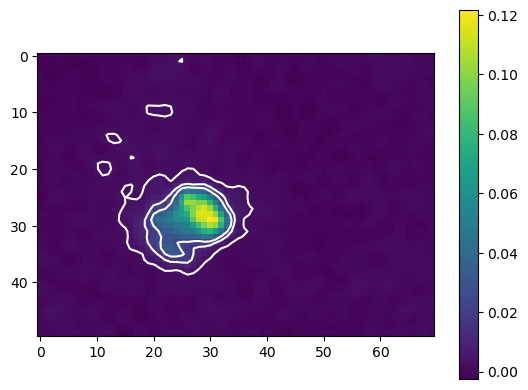

In [32]:
# q 5.11
# Plotting the first plane of the previous data cube

import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt')
data_cube = data.reshape((40, 50, 70))
plane_1 = data_cube[0]

plt.imshow(plane_1, origin='lower', cmap='viridis')
plt.colorbar()

# Calculate mean and std
mean_val = np.mean(plane_1)
std_val = np.std(plane_1)

# Draw contours with 3 levels: [mean, mean+std, mean+2*std]
contour_levels = [mean_val, mean_val + std_val, mean_val + 2*std_val]
plt.contour(plane_1, levels=contour_levels, colors='white', origin='lower')

plt.show()

In [33]:
# q 5.12
from scipy.constants import c 
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        v = self.redshift() * (c/1000)
        return v

# Random example
my_galaxy = Galaxy("M31", 3969)

print(f"Galaxy name: {my_galaxy.name}")
print(f"Velocity: {my_galaxy.velocity():.2f} km/s")

Galaxy name: M31
Velocity: 37.77 km/s


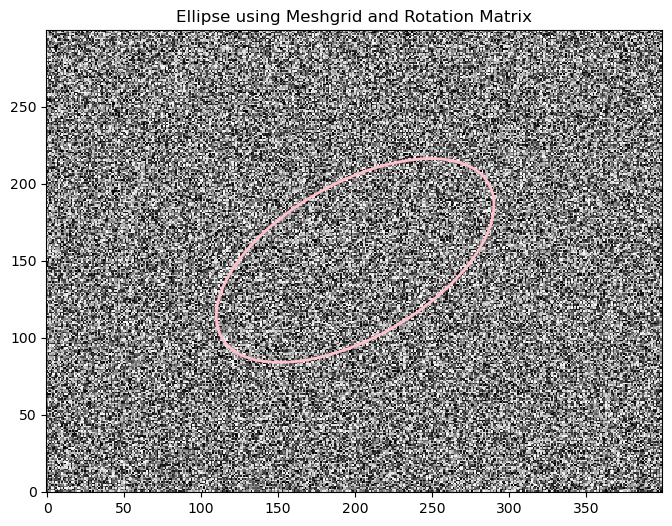

In [21]:
# q 5.13
import numpy as np
from matplotlib.pyplot import figure, show

# Create dummy 2D array
Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(data, interpolation='none', origin="lower", cmap='gray')

# Plot ellipse in the middle
x_mid = Nx // 2
y_mid = Ny // 2

a = 100 # semi-major axis
b = 50 # semi-minor axis
theta = np.radians(30) # Convert position angle to radians

# Coord grid centered at the middle
x = np.arange(Nx) - Nx /2
y = np.arange(Ny) - Ny /2
X, Y = np.meshgrid(x, y)

# Now we have to rotate the axes of the ellipse to match the coord grid
X_rot = X * np.cos(theta) + Y * np.sin(theta)
Y_rot = -X * np.sin(theta) + Y * np.cos(theta)

ellipse_func = (X_rot**2 / a**2) + (Y_rot**2 / b**2)

ax.contour(X + x_mid, Y + y_mid, ellipse_func, levels=[1], colors='pink', linewidths=2)

ax.set_title("Ellipse using Meshgrid and Rotation Matrix")
plt.show()